In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import csv
import os
import numpy as np
import torch
from torch.utils.data import Dataset

class Gesture3DDataset(Dataset):
    def __init__(self, csv_file, split="train"):
        """
        csv_file: path to your CSV with [filepath,label,split]
        split: one of ["train", "val", "test"]
        """
        self.samples = []
        
        # 1. Read CSV, store (filepath, label) only for this `split`
        with open(csv_file, "r") as f:
            reader = csv.DictReader(f)
            for row in reader:
                if row["split"] == split:
                    self.samples.append((row["filepath"], row["label"]))

        # 2. Build a label_to_idx dict so we can convert label strings -> int
        all_labels = sorted(list(set(s[1] for s in self.samples)))
        self.label_to_idx = {lab: i for i, lab in enumerate(all_labels)}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label_str = self.samples[idx]
        
        # 3. Load .npy array of shape (120, 64, 64)
        arr = np.load(filepath)  # shape: (T=120, H=64, W=64), dtype=uint8

        # 4. Add channel dimension => (1, 120, 64, 64)
        # Because PyTorch 3D conv typically expects (C, D, H, W).
        # Here D=120 is 'time', H=64, W=64, and we have 1 channel (grayscale).
        arr = np.expand_dims(arr, axis=0)  # shape (1, 120, 64, 64)

        # Convert to float, optional normalization [0..1] if you like:
        arr = arr.astype(np.float32) / 255.0  # scale to [0..1]

        # 5. Convert to torch tensor
        x = torch.from_numpy(arr)  # shape: (1, 120, 64, 64)

        # 6. Convert label string -> int
        label_idx = self.label_to_idx[label_str]
        y = torch.tensor(label_idx, dtype=torch.long)

        return x, y


class Simple3DCNN(nn.Module):
    """
    A very basic 3D CNN that expects input of shape:
      (batch_size, 1, 120, 64, 64)
    You might need to adjust pool sizes if you run out of dims.
    """
    def __init__(self, num_classes=20):
        super(Simple3DCNN, self).__init__()
        
        # 1st conv block
        self.conv1 = nn.Conv3d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm3d(32)
        self.pool1 = nn.MaxPool3d(kernel_size=(2, 2, 2))  # reduce time, height, width by factor of 2

        # 2nd conv block
        self.conv2 = nn.Conv3d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm3d(64)
        self.pool2 = nn.MaxPool3d(kernel_size=(2, 2, 2))

        # 3rd conv block
        self.conv3 = nn.Conv3d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm3d(128)
        self.pool3 = nn.MaxPool3d(kernel_size=(2, 2, 2))

        # After 3 layers of pooling, we drastically reduce T, H, W.
        # Let's see: 120 -> 60 -> 30 -> 15 in time dimension,
        # and 64 -> 32 -> 16 -> 8 in height/width.

        # We'll flatten and use a fully-connected layer
        # 128 * 15 * 8 * 8 = 128 * 15 * 64 * 8 = 128 * 7680 ... that might still be big
        # Let's do an adaptive avg pool so we don't have to manually compute
        self.avgpool = nn.AdaptiveAvgPool3d((1, 1, 1))  # this squashes all dims to 1

        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # shape (batch, 1, 120, 64, 64)
        x = self.pool1(self.bn1(F.relu(self.conv1(x))))  # => (batch, 32, 60, 32, 32)
        x = self.pool2(self.bn2(F.relu(self.conv2(x))))  # => (batch, 64, 30, 16, 16)
        x = self.pool3(self.bn3(F.relu(self.conv3(x))))  # => (batch, 128, 15, 8, 8)

        # adaptive avg pool => (batch, 128, 1, 1, 1)
        x = self.avgpool(x)
        # flatten
        x = x.view(x.size(0), -1)  # shape (batch, 128)
        # classify
        x = self.fc(x)            # shape (batch, num_classes)
        return x
    


def load_trained_model(weights_path, num_classes=20, device='cpu'):
    """
    Load the trained Simple3DCNN (or any other 3D CNN) from disk.
    """
    # Ensure you have the same model definition as used in training
    model = Simple3DCNN(num_classes=num_classes)
    
    # Load weights
    state_dict = torch.load(weights_path, map_location=device)
    model.load_state_dict(state_dict)
    
    model.to(device)
    model.eval()
    return model

def predict_npy(model, npy_path, idx_to_label=None, device='cpu'):
    """
    model: a loaded 3D CNN in eval mode
    npy_path: path to the unseen .npy (shape (120,64,64))
    idx_to_label: dict mapping {class_idx -> label_str} (optional)
    device: 'cpu' or 'cuda'
    
    Returns:
      pred_label (str or int): predicted class (string label if idx_to_label provided)
      prob_dict (dict or None): probability distribution per class, if idx_to_label is given
    """
    # 1. Load the frames array
    arr = np.load(npy_path)  # shape: (120, 64, 64)
    
    # 2. Insert channel dimension: shape (1, 120, 64, 64)
    arr = np.expand_dims(arr, axis=0)
    
    # 3. Convert to float and normalize
    arr = arr.astype(np.float32) / 255.0
    
    # 4. Unsqueeze a batch dimension => shape (batch=1, channels=1, frames=120, height=64, width=64)
    # PyTorch expects (N, C, D, H, W) for 3D conv
    tensor = torch.from_numpy(arr).unsqueeze(0).to(device)
    # shape: (1, 1, 120, 64, 64)
    
    # 5. Model forward
    with torch.no_grad():
        logits = model(tensor)  # shape (1, num_classes)
    
    # 6. Softmax for probabilities
    probs = F.softmax(logits, dim=1)  # shape (1, num_classes)
    
    # 7. Argmax
    _, pred_idx = torch.max(probs, dim=1)  # shape (1,)
    pred_idx = pred_idx.item()
    
    # Build a dictionary of label -> prob
    prob_values = probs.squeeze(0).cpu().numpy()  # shape (num_classes,)
    
    # If we have a class index->label map, decode
    if idx_to_label:
        pred_label = idx_to_label[pred_idx]
        # build a prob_dict
        prob_dict = {}
        for i, p in enumerate(prob_values):
            label_str = idx_to_label[i]
            prob_dict[label_str] = float(p)
    else:
        pred_label = pred_idx
        prob_dict = None
    
    return pred_label, prob_dict


if __name__ == "__main__":
    import json
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Suppose you have 20 classes
    num_classes = 20
    weights_path = "simple_3dcnn_gray64_20_epoch.pth"  # your trained model weights
    
    model = load_trained_model(weights_path, num_classes=num_classes, device=device)
    
    # If you have an index-to-label mapping from your dataset
    # Example:

    from torch.utils.data import DataLoader

    # Rebuild the same dataset from your CSV (the same one you used for training)
    train_dataset = Gesture3DDataset(
        csv_file="dataset_split.csv",  # or whatever your CSV is named
        split="train"
    )

    # Now get the label_to_idx dict from train_dataset
    label_to_idx = train_dataset.label_to_idx  # e.g. {"right":0, "left":1, ...}

    # Invert it: idx->label
    idx_to_label = {v: k for k, v in label_to_idx.items()}


    
    # Example .npy from your new test_videos folder
    #test_npy_path = "unseen_test_videos/class/class-test.npy"  # shape (120,64,64)
    #test_npy_path = "unseen_test_videos/class/class-test2.npy"  # shape (120,64,64)
    #test_npy_path = "unseen_test_videos/class/class-test-3.npy"  # shape (120,64,64)
    #test_npy_path = "unseen_test_videos/room/room-test.npy"  # shape (120,64,64)
    #test_npy_path = "unseen_test_videos/room/room-test2.npy"  # shape (120,64,64)
    #test_npy_path = "unseen_test_videos/teach/teach-test.npy"  # shape (120,64,64)
    test_npy_path = "unseen_test_videos/teach/teach-test-2.npy"  # shape (120,64,64)

    pred_label, prob_dict = predict_npy(
        model=model,
        npy_path=test_npy_path,
        idx_to_label=idx_to_label,
        device=device
    )
    
    print(f"Predicted label: {pred_label}")
    print("Probabilities:")
    if prob_dict:
        for lbl, p in prob_dict.items():
            print(f"  {lbl}: {p*100:.2f}%")


Predicted label: teach
Probabilities:
  answer: 0.00%
  bicycle: 0.02%
  book: 0.03%
  break: 0.00%
  car: 0.05%
  class: 12.33%
  correct: 0.02%
  die: 0.01%
  exam: 0.01%
  how: 0.47%
  left: 0.18%
  lose: 0.06%
  model: 0.08%
  now: 1.04%
  page: 0.53%
  right: 0.01%
  room: 0.02%
  teach: 85.13%
  train: 0.00%
  walk: 0.01%


/var/folders/js/b36xj6rs3k1c5z78dsb4p3p00000gn/T/ipykernel_44274/2098794844.py:116: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights_path, map_l

/var/folders/js/b36xj6rs3k1c5z78dsb4p3p00000gn/T/ipykernel_44274/2098794844.py:116: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights_path, map_l

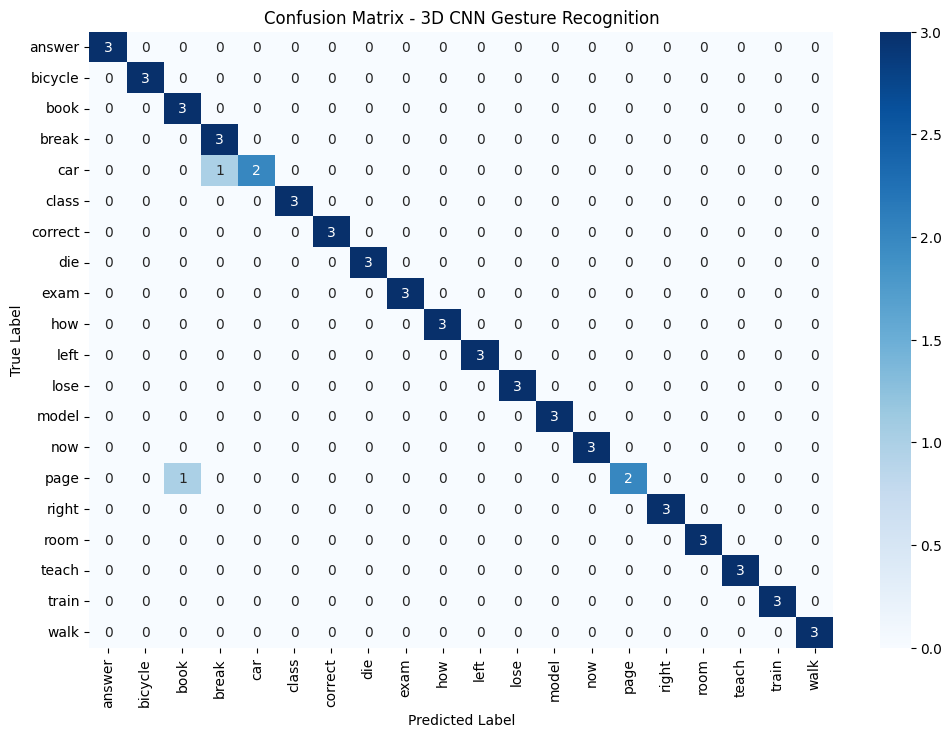


Classification Report:

              precision    recall  f1-score   support

      answer       1.00      1.00      1.00         3
     bicycle       1.00      1.00      1.00         3
        book       0.75      1.00      0.86         3
       break       0.75      1.00      0.86         3
         car       1.00      0.67      0.80         3
       class       1.00      1.00      1.00         3
     correct       1.00      1.00      1.00         3
         die       1.00      1.00      1.00         3
        exam       1.00      1.00      1.00         3
         how       1.00      1.00      1.00         3
        left       1.00      1.00      1.00         3
        lose       1.00      1.00      1.00         3
       model       1.00      1.00      1.00         3
         now       1.00      1.00      1.00         3
        page       1.00      0.67      0.80         3
       right       1.00      1.00      1.00         3
        room       1.00      1.00      1.00         3
  

In [3]:
import torch
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Load dataset and model
test_dataset = Gesture3DDataset(csv_file="dataset_split.csv", split="test")
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
num_classes = len(test_dataset.label_to_idx)
weights_path = "simple_3dcnn_gray64_20_epoch.pth"
model = load_trained_model(weights_path, num_classes=num_classes, device=device)

# Get label mappings
label_to_idx = test_dataset.label_to_idx
idx_to_label = {v: k for k, v in label_to_idx.items()}  # Reverse mapping

# Initialize lists for true and predicted labels
true_labels = []
predicted_labels = []

# Perform inference on the test dataset
model.eval()
with torch.no_grad():
    for x, y_true in test_loader:
        x, y_true = x.to(device), y_true.to(device)

        # Forward pass
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        y_pred = torch.argmax(probs, dim=1)

        # Store results
        true_labels.append(y_true.item())
        predicted_labels.append(y_pred.item())

# Convert index-based labels to actual label names
true_labels_names = [idx_to_label[i] for i in true_labels]
predicted_labels_names = [idx_to_label[i] for i in predicted_labels]

# Compute confusion matrix
cm = confusion_matrix(true_labels_names, predicted_labels_names, labels=list(idx_to_label.values()))

# Display confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=idx_to_label.values(), yticklabels=idx_to_label.values())
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - 3D CNN Gesture Recognition")
plt.show()

# Print classification report
print("\nClassification Report:\n")
print(classification_report(true_labels_names, predicted_labels_names, target_names=list(idx_to_label.values())))


Processing class: right
Test File: right-test-5.npy | True Label: right | Predicted: right
Probabilities:
  right: 87.42%
  page: 3.80%
  lose: 2.79%
  left: 2.36%
  book: 1.99%
--------------------------------------------------
Test File: right-test-4.npy | True Label: right | Predicted: right
Probabilities:
  right: 58.86%
  left: 20.27%
  lose: 9.64%
  page: 5.63%
  model: 2.01%
--------------------------------------------------


/var/folders/js/b36xj6rs3k1c5z78dsb4p3p00000gn/T/ipykernel_44274/2098794844.py:116: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights_path, map_l

Test File: right-test-3.npy | True Label: right | Predicted: right
Probabilities:
  right: 73.62%
  left: 14.56%
  page: 4.84%
  now: 2.34%
  book: 2.08%
--------------------------------------------------
Test File: right-test-2.npy | True Label: right | Predicted: right
Probabilities:
  right: 89.50%
  left: 4.48%
  page: 2.44%
  book: 1.91%
  now: 0.47%
--------------------------------------------------
Test File: right-test-1.npy | True Label: right | Predicted: right
Probabilities:
  right: 62.95%
  left: 22.13%
  page: 9.02%
  book: 1.90%
  lose: 0.90%
--------------------------------------------------
Processing class: page
Test File: page-test-5.npy | True Label: page | Predicted: page
Probabilities:
  page: 44.99%
  right: 27.86%
  book: 17.24%
  lose: 3.03%
  how: 1.83%
--------------------------------------------------
Test File: page-test-4.npy | True Label: page | Predicted: page
Probabilities:
  page: 69.77%
  book: 17.89%
  right: 7.34%
  now: 1.76%
  lose: 1.11%
--------

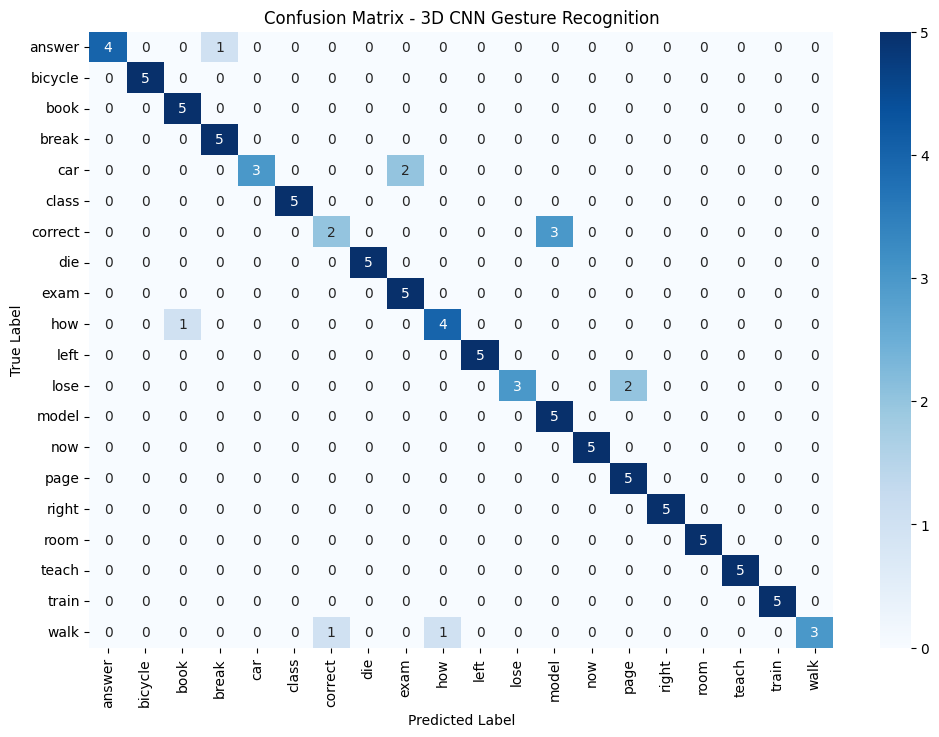


=== Classification Report ===

              precision    recall  f1-score   support

      answer       1.00      0.80      0.89         5
     bicycle       1.00      1.00      1.00         5
        book       0.83      1.00      0.91         5
       break       0.83      1.00      0.91         5
         car       1.00      0.60      0.75         5
       class       1.00      1.00      1.00         5
     correct       0.67      0.40      0.50         5
         die       1.00      1.00      1.00         5
        exam       0.71      1.00      0.83         5
         how       0.80      0.80      0.80         5
        left       1.00      1.00      1.00         5
        lose       1.00      0.60      0.75         5
       model       0.62      1.00      0.77         5
         now       1.00      1.00      1.00         5
        page       0.71      1.00      0.83         5
       right       1.00      1.00      1.00         5
        room       1.00      1.00      1.00      

In [4]:
import torch
import os
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Define paths
TEST_DIR = "unseen_test_videos"  # Root folder containing subfolders for each class
CSV_PATH = "dataset_split.csv"   # Your dataset split CSV
WEIGHTS_PATH = "simple_3dcnn_gray64_20_epoch.pth"  # Path to trained model weights
OUTPUT_FILE = "test_results_last.txt"  # File to save the results

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load dataset (for label mappings)
test_dataset = Gesture3DDataset(csv_file=CSV_PATH, split="test")
label_to_idx = test_dataset.label_to_idx  # e.g. {"right":0, "left":1, ...}
idx_to_label = {v: k for k, v in label_to_idx.items()}  # Reverse mapping

# Load trained model
num_classes = len(label_to_idx)
model = load_trained_model(WEIGHTS_PATH, num_classes=num_classes, device=device)

# Lists to store results
true_labels = []
predicted_labels = []

# Open a file to write results
with open(OUTPUT_FILE, "w") as f:
    
    # Loop over all folders (gesture classes) in unseen_test_videos
    for class_name in os.listdir(TEST_DIR):
        class_folder = os.path.join(TEST_DIR, class_name)
        
        if not os.path.isdir(class_folder):
            continue  # Skip if not a directory
        
        f.write(f"Processing class: {class_name}\n")
        print(f"Processing class: {class_name}")
        
        for file in os.listdir(class_folder):
            if file.endswith(".npy"):  # Ensure we only process .npy files
                npy_path = os.path.join(class_folder, file)
                
                # Predict using the trained model
                pred_label, prob_dict = predict_npy(
                    model=model,
                    npy_path=npy_path,
                    idx_to_label=idx_to_label,
                    device=device
                )
                
                # Store ground truth and predicted labels
                true_labels.append(class_name)  # Ground truth class
                predicted_labels.append(pred_label)  # Model predicted class

                # Write & Print results for each sample
                f.write(f"Test File: {file} | True Label: {class_name} | Predicted: {pred_label}\n")
                print(f"Test File: {file} | True Label: {class_name} | Predicted: {pred_label}")
                
                f.write("Probabilities:\n")
                print("Probabilities:")
                
                if prob_dict:
                    for lbl, p in sorted(prob_dict.items(), key=lambda x: x[1], reverse=True)[:5]:  # Show top 5
                        f.write(f"  {lbl}: {p*100:.2f}%\n")
                        print(f"  {lbl}: {p*100:.2f}%")
                
                f.write("-" * 50 + "\n")
                print("-" * 50)

    # Generate Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_labels, labels=list(label_to_idx.keys()))

    # Save Confusion Matrix to File
    f.write("\n=== Confusion Matrix ===\n")
    f.write(np.array2string(cm) + "\n")

    # Display Confusion Matrix
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_to_idx.keys(), yticklabels=label_to_idx.keys())
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - 3D CNN Gesture Recognition")
    plt.savefig("confusion_matrix.png")  # Save as an image
    plt.show()

    # Generate Classification Report
    report = classification_report(true_labels, predicted_labels, target_names=list(label_to_idx.keys()))

    # Print & Save Classification Report
    f.write("\n=== Classification Report ===\n")
    f.write(report + "\n")
    print("\n=== Classification Report ===\n")
    print(report)

print(f"\nAll results have been saved to {OUTPUT_FILE} ✅")
